In [1]:
import matplotlib.pyplot as plt
import time
import random
from collections import deque
import tensorflow as tf
from tqdm import tqdm 
from tensorflow.keras import Sequential 
from tensorflow.keras.activations import relu, linear
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import RMSprop
import math
from tensorflow.keras.optimizers import Adam
from IPython.display import clear_output
from random import sample
from tqdm import trange
import pandas as pd
import gc
import os
import numpy as np 
import time
import copy


In [2]:
physical_devices = tf.config.list_physical_devices('GPU')
print("Num GPUs:", len(physical_devices))


Num GPUs: 1


In [3]:
state_space=2
obs_space=2
action_space=3
intermediate_dim=16

In [4]:
all_states=[]
for i in range(0,21):
    all_states.append(i-10)
all_actions=[0,1,2]
all_states

[-10, -9, -8, -7, -6, -5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

In [5]:
class QModel:
    def __init__(self, input_dim, output_dim, lr):
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.lr = lr
        self.Qpolicy = self.create()
        self.Qtarget = self.create() 
        self.Qtarget.set_weights(self.Qpolicy.get_weights())
        
    def create(self):
        model = Sequential()
        model.add(tf.keras.layers.InputLayer(input_shape=(1,state_space)))
        model.add(Dense(512,activation = 'relu'))
        model.add(Dense(256, activation = 'relu'))
        model.add(Dense(128, activation = 'relu'))
        model.add(Dense(self.output_dim, activation = 'linear'))
        model.compile(optimizer =tf.keras.optimizers.legacy.Adam(learning_rate=self.lr), loss = "mse", metrics = ['accuracy'])
        return model

In [6]:
GAMMA = 0.995
LEARNING_RATE = 1e-6

MEMORY_SIZE = 10000
BATCH_SIZE = 32

EPSILON_MAX = 1.0
EPSILON_MIN = 0.1
EXPLORATION_DECAY = 0.997

In [7]:
class DQNSolver:
    def __init__(self,state_space,action_space, decay_coe = 0.99, 
                  memory_size = MEMORY_SIZE,EXPLORATION_DECAY=EXPLORATION_DECAY,LEARNING_RATE=LEARNING_RATE,EPSILON_MAX=EPSILON_MAX,EPSILON_MIN=EPSILON_MIN,BATCH_SIZE=BATCH_SIZE):
        
        #self.env = gym.make('CartPole-v0')

        self.states = state_space
        self.n_actions = action_space
        
        self.actions = [i for i in range(self.n_actions)]
        
        self.lr = LEARNING_RATE
        self.gamma = GAMMA
        self.epsilon = EPSILON_MAX
        self.decay_coe = decay_coe
        self.min_eps = EPSILON_MIN
        #self.episodes = episodes
        self.batch_size = BATCH_SIZE
        self.memory = deque(maxlen = memory_size) # replay memory 
        
        self.terminal_state = False # end of the episode
        self.target_counter = 0 
        
        # Plot data
        #self.timestep = self.episodes / 10

        
        
        
        self.model = QModel((1,self.states), self.n_actions, self.lr)
        # Smooth epsilon 
        # self.a = 0.35
        # self.b = 0.1
        # self.c = 0.01
        
    def state_shape(self,states):
        states = np.array(states)
        return states.reshape(-1,*states.shape)
    def update_target_model(self):
        """
        Updates the current target_q_net with the q_net which brings all the
        training in the q_net to the target_q_net.
        :return: None
        """
        self.model.Qtarget.set_weights(self.model.Qpolicy.get_weights())
    def decrement_epsilon(self):
        '''
        if self.epsilon > self.min_eps:
            self.epsilon *= self.decay_coe
        else:
            self.epsilon = self.min_eps
        '''
        # s_time = (time - self.a*self.episodes) / (self.b*self.episodes) 
        # cosh = np.cosh(math.exp(-s_time))
        # self.epsilon = 1 - (1/cosh + (time*self.c/self.episodes))
        if self.epsilon>self.min_eps:
            self.epsilon*=EXPLORATION_DECAY
        else:
            self.epsilon=self.min_eps
    def forget(self):
        self.memory.clear()

    def remember(self, s, a, r, s_, done):
        self.memory.append([self.state_shape(s), a, r, self.state_shape(s_), done])
        
    def act(self, states):
        if np.random.random() > (1 - self.epsilon):
            action = np.random.choice(self.actions,1,p=[1/3,1/3,1/3])[0]
        else:
            states = self.state_shape(states)
            states.reshape(1,1,self.states)
#             states=[states]
#             states=np.array(states)
            #print(states.shape)
            action = np.argmax(np.array(self.model.Qpolicy.predict_on_batch(states)))
            
        return action
            
    def minibatch(self):
        if np.random.random() > 0.1:
            return random.sample(self.memory, self.batch_size)
        else:
            x=list(self.memory)
            x.sort(key=lambda x: x[2],reverse=True)
            return x[:self.batch_size]
    

        #plt.savefig(r'RL/loss - e{}v2.png'.format(episode), dpi = 500)
        
    def train(self):
        # X - states passed to the NN, y - target
        
        X, y = [], []
        
        if len(self.memory) >= self.batch_size: 
            SARS = self.minibatch()
            s =np.array( [row[0] for row in SARS])
            s=s.reshape(BATCH_SIZE,1,state_space)
            #print(s.shape)
            qvalue = np.array(self.model.Qpolicy.predict_on_batch(s))
            #print(qvalue)
            s_ =np.array( [row[3] for row in SARS])
            s_=s_.reshape(BATCH_SIZE,1,state_space)
            future_qvalue = np.array(self.model.Qtarget.predict_on_batch(s_))
            #print("2")
            #print(future_qvalue)

            for index, (state, action, reward, state_, done) in enumerate(SARS):
                if done == True:
                    Qtarget = reward
                else:
                    Qtarget = reward + self.gamma * np.max(future_qvalue[index][0])
            
                qcurr = qvalue[index][0]
                #print(qcurr)
                qcurr[int(action)] = Qtarget 
                #print(qcurr)
                X.append(state)
                y.append(qcurr)
#             X_dataset=tf.data.Dataset.from_tensor_slices(X).batch(64)
#             y_dataset=tf.data.Dataset.from_tensor_slices(y).batch(64)
#             final_dataset=tf.data.Dataset.zip((X_dataset, y_dataset))
            X, y = np.array(X).reshape(self.batch_size,1,self.states), np.array(y).reshape(self.batch_size, 1, self.n_actions)
                                 
            loss = self.model.Qpolicy.train_on_batch(X, y,return_dict=True)
            
            

In [8]:
class Non_Markovian_Environment:

    def __init__(self,memory_len,action_space,all_states,all_actions,probability_matrix) -> None:
        self.all_states=all_states
        self.all_actions=all_actions
        # self.memory=deque(maxlen=memory_len)
        self.memory=0
        self.action_space=action_space
        self.probability_matrix=probability_matrix
    def reset(self):
        self.memory=0
        # self.memory.append(np.array([[0]]))
        # self.memory.append(np.array([[0]]))
        return np.array([random.choice(self.all_states),0])
    # def clear_memory(self):
    #     self.memory.clear()

    def remember(self,state):
        # self.memory.append(state)
        self.memory+=state[0][0]
    def step(self,state,action):
        x=copy.deepcopy(state)
        done=False
        actions=[-1,0,1]
        new_state_temp=0
        # print(sum(self.memory))
        # print(self.memory)
        new_state_temp=x+(self.memory)%3-1+actions[action]
        # print((sum(self.memory)[0][0]+action)%5)
        # print(x)
        # print("-----")
        # print(new_state_temp)
        # noise=np.random.choice([-2,-1,0,1,2],replace=True,p=self.probability_matrix)
        # print(self.all_actions)
        # print(noise)
        new_state=new_state_temp
        if(new_state>10):
            new_state=10
        if(new_state<-10):
            new_state=-10
        if(new_state==0):
            reward=100
            done=True
        else:
            reward=-abs(new_state)/10
            # if new_state>50:
            #     reward=state-new_state
            # else:
            #     reward=new_state-state
            done=False
        return [np.array([new_state,(self.memory+new_state)%3]),reward,done]
    
        
        
    
        
        

In [9]:
dqn_solver=DQNSolver(state_space=state_space,action_space=action_space)
env=Non_Markovian_Environment(memory_len=3,action_space=action_space,all_states=all_states,all_actions=all_actions,probability_matrix=[0.05,0.2,0.5,0.2,.05])

2023-12-01 22:57:41.343179: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2023-12-01 22:57:41.343197: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2023-12-01 22:57:41.343203: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2023-12-01 22:57:41.343239: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2023-12-01 22:57:41.343256: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [10]:
env.reset()

array([0, 0])

In [11]:
def data_collection(total_episodes,dqn_solver):


    O_series=[]
    U_series=[]
    R_series=[]
    Done_series=[]
    # O_series.append(np.array([[0.0]]))
    
    sum=0
    ep_no=0
    i=0
    while(ep_no<total_episodes):
        o=env.reset()
        print(o)
        o=np.reshape(o,(1,obs_space))
        #s0=np.reshape(s0,[1,state_space])
        env.remember(o)
        step=0
        done=False
        j=0
        while (not done) and (j<200) :
            j+=1
            
                # s=s.tolist()
                # s[0][0]=np.tanh(s[0][0])*4.8
                # s[0][2]=np.tanh(s[0][2])*0.418
                # s=np.array(s)
                

            o=np.reshape(o,(1,obs_space))
            O_series.append(o)
            if((i>0)and (not(step==0))):
                dqn_solver.remember(O_series[i-1][0],U_series[i-1][0][0],R_series[i-1],O_series[i][0],Done_series[i-1])
                dqn_solver.train()
            action=dqn_solver.act(o)

            obs, reward, done= env.step(o[0][0],int(action))
            
            Done_series.append(done)
            action=np.array([[action]])
            action=action.astype('float32')
            U_series.append(action)
            obs=np.reshape(obs,[1,obs_space])
            env.remember(obs)
            
            R_series.append(reward)
            if done==True:
                dqn_solver.remember(o[0],action[0][0],100,obs[0],True)
                dqn_solver.train()
            o=obs
            
            # print(s.shape)
            # print(action.shape)
            i+=1
            step+=1
        ep_no+=1
    return O_series,U_series,R_series,Done_series

In [12]:
# def dqn_training(dqn_solver,epochs,O_series,U_series,R_series,Done_series):
#     #dqn_solver.forget()
#     for i in range(len(O_series)-1):
#         dqn_solver.remember(O_series[i][0],U_series[i][0][0],R_series[i],O_series[i+1][0],Done_series[i])
#     for j in trange(epochs):
#         dqn_solver.train()
#         if(j%5==0):
#             dqn_solver.update_target_model()

In [13]:
rewards_storage=[]


In [14]:
start_state_reward=[]

In [15]:
dqn_solver.epsilon=1

In [16]:
def complete_loop(dqn_solver,epochs):
    for epoch in range(epochs):
        O_series,U_series,R_series,Done_series=data_collection(1,dqn_solver)
        print("epoch: {}, total reward: {}".format(epoch, sum(R_series)))
        rewards_storage.append(sum(R_series))
        start_state_reward.append([O_series[0][0],sum(R_series)])
        # dqn_training(dqn_solver,1000,O_series,U_series,R_series,Done_series)#50,500
        if epoch<100:
            dqn_solver.epsilon=1
        else:
            dqn_solver.decrement_epsilon()
        clear_output(wait=True)

In [17]:
complete_loop(dqn_solver,1000)


[-9  0]
epoch: 999, total reward: 71.4


In [66]:
SARS=dqn_solver.minibatch()
print(SARS)

[[array([[-1,  0]]), 0.0, 100, array([[0, 2]]), True], [array([[-1,  2]]), 1.0, 100, array([[0, 1]]), True], [array([[1, 0]]), 2.0, 100, array([[0, 1]]), True], [array([[-1,  2]]), 1.0, 100, array([[0, 1]]), True], [array([[-1,  2]]), 1.0, 100, array([[0, 1]]), True], [array([[1, 0]]), 2.0, 100, array([[0, 1]]), True], [array([[-1,  2]]), 1.0, 100, array([[0, 1]]), True], [array([[-1,  0]]), 0.0, 100, array([[0, 2]]), True], [array([[1, 1]]), 1.0, 100, array([[0, 2]]), True], [array([[1, 1]]), 1.0, 100, array([[0, 2]]), True], [array([[1, 0]]), 2.0, 100, array([[0, 1]]), True], [array([[1, 1]]), 1.0, 100, array([[0, 2]]), True], [array([[1, 0]]), 2.0, 100, array([[0, 1]]), True], [array([[-1,  0]]), 0.0, 100, array([[0, 2]]), True], [array([[-1,  2]]), 1.0, 100, array([[0, 1]]), True], [array([[-1,  2]]), 1.0, 100, array([[0, 1]]), True], [array([[-1,  2]]), 1.0, 100, array([[0, 1]]), True], [array([[1, 1]]), 1.0, 100, array([[0, 2]]), True], [array([[-1,  2]]), 1.0, 100, array([[0, 1]

In [20]:
for index, (state, action, reward, state_, done) in enumerate(SARS):
    print(reward)
    break

-0.9


In [21]:
# complete_loop(dqn_solver,1000)


In [22]:
start_state_reward[0][0][0]

-3

In [34]:
dict={}
freq_dict={}
for val in start_state_reward:
    if val[0][0] in freq_dict.keys():
        freq_dict[val[0][0]]+=1
    else:
        freq_dict[val[0][0]]=1

In [35]:
for val in start_state_reward:
    if val[0][0] in dict.keys():
        dict[val[0][0]]=dict[val[0][0]]+val[1]/freq_dict[val[0][0]]
    else:
        dict[val[0][0]]=val[1]/freq_dict[val[0][0]]

myKeys = list(dict.keys())
myKeys.sort()
sorted_dict = {i: dict[i] for i in myKeys}

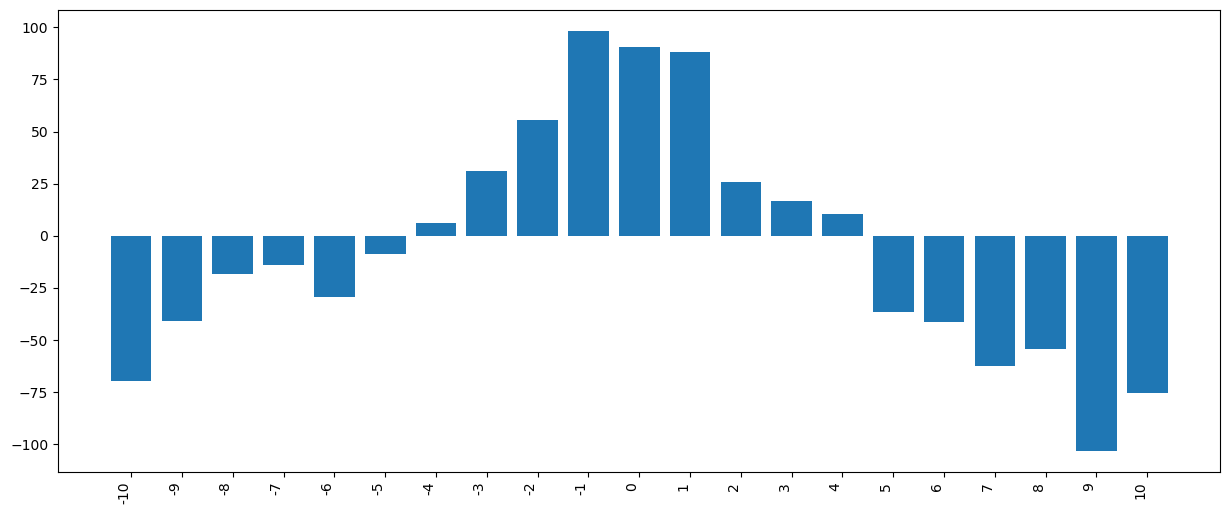

In [36]:
names = list(sorted_dict.keys())
values = list(sorted_dict.values())
plt.figure(figsize=(15,6))
plt.bar(range(len(dict)), values, tick_label=names)
plt.xticks(rotation=90, ha='right')
plt.show()


In [27]:
O_series,U_series,R_series,Done_series=data_collection(1,dqn_solver)


[5 0]


In [41]:
O_series[10:20]

[array([[8, 2]]),
 array([[7, 1]]),
 array([[7, 2]]),
 array([[8, 0]]),
 array([[8, 2]]),
 array([[7, 1]]),
 array([[7, 2]]),
 array([[8, 0]]),
 array([[8, 2]]),
 array([[7, 1]])]

In [42]:
U_series[10:20]

[array([[2.]], dtype=float32),
 array([[2.]], dtype=float32),
 array([[2.]], dtype=float32),
 array([[2.]], dtype=float32),
 array([[2.]], dtype=float32),
 array([[2.]], dtype=float32),
 array([[2.]], dtype=float32),
 array([[2.]], dtype=float32),
 array([[2.]], dtype=float32),
 array([[2.]], dtype=float32)]

In [44]:
dqn_solver.model.Qpolicy(np.array([[[8,0]]]))

<tf.Tensor: shape=(1, 1, 3), dtype=float32, numpy=array([[[ -0.94761235, -10.264621  ,   0.168517  ]]], dtype=float32)>

In [67]:
R_series

[-0.6,
 -0.5,
 -0.5,
 -0.6,
 -0.7,
 -0.7,
 -0.6,
 -0.5,
 -0.5,
 -0.6,
 -0.7,
 -0.7,
 -0.6,
 -0.5,
 -0.5,
 -0.6,
 -0.7,
 -0.7,
 -0.6,
 -0.5,
 -0.5,
 -0.6,
 -0.7,
 -0.7,
 -0.6,
 -0.5,
 -0.5,
 -0.6,
 -0.7,
 -0.7,
 -0.6,
 -0.5,
 -0.5,
 -0.6,
 -0.7,
 -0.7,
 -0.6,
 -0.5,
 -0.5,
 -0.6,
 -0.7,
 -0.7,
 -0.6,
 -0.5,
 -0.6,
 -0.5,
 -0.6,
 -0.6,
 -0.5,
 -0.4,
 -0.4,
 -0.5,
 -0.6,
 -0.7,
 -0.7,
 -0.6,
 -0.5,
 -0.5,
 -0.6,
 -0.7,
 -0.7,
 -0.6,
 -0.5,
 -0.5,
 -0.6,
 -0.7,
 -0.7,
 -0.6,
 -0.5,
 -0.5,
 -0.6,
 -0.7,
 -0.7,
 -0.6,
 -0.5,
 -0.5,
 -0.6,
 -0.7,
 -0.7,
 -0.6,
 -0.5,
 -0.5,
 -0.6,
 -0.7,
 -0.7,
 -0.6,
 -0.5,
 -0.5,
 -0.6,
 -0.7,
 -0.7,
 -0.6,
 -0.5,
 -0.5,
 -0.6,
 -0.7,
 -0.7,
 -0.6,
 -0.5,
 -0.5]

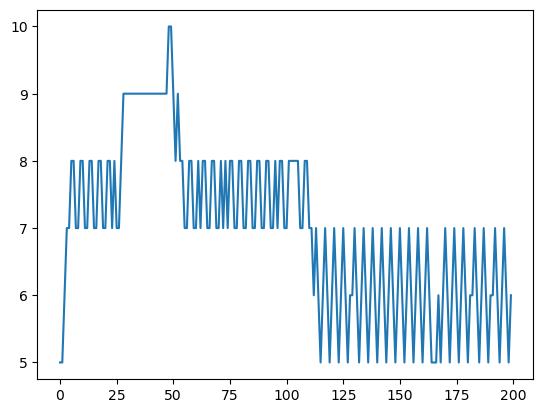

In [28]:
plt.plot([x[0][0] for x in O_series])

In [17]:
# complete_loop(dqn_solver,100)

In [31]:
# dqn_solver.epsilon=1

In [77]:
dqn_solver.act(O_series[0])[0]

4

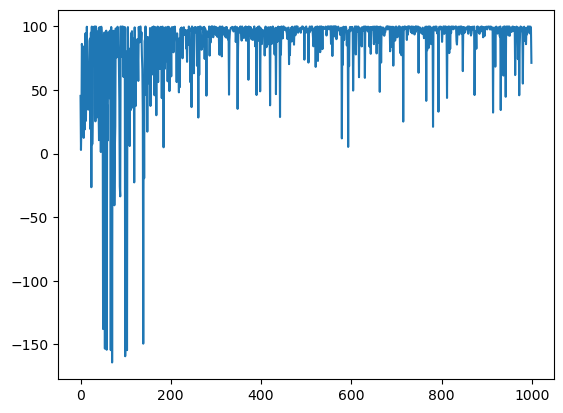

In [18]:
plt.plot(rewards_storage)

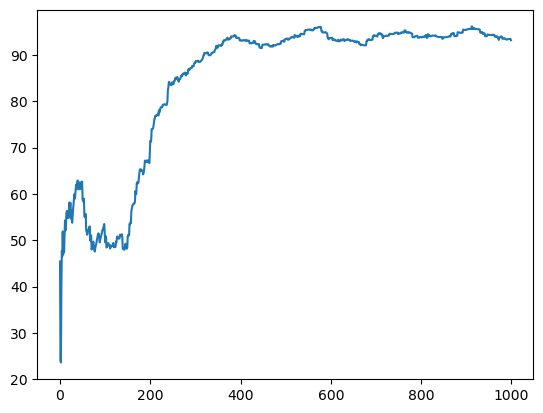

In [19]:
df=pd.DataFrame()
df['rewards']=rewards_storage
plt.plot(df['rewards'].rolling(100,min_periods=1).mean())

In [28]:
df.to_csv('28_11_completely_O.csv')

In [33]:
df1=pd.read_csv('rewards_non_markov_24-11.csv')

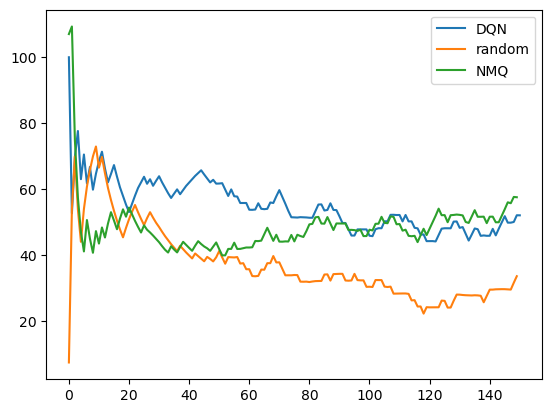

In [46]:
plt.plot(df['rewards'].rolling(50,min_periods=1).mean(),label='DQN')
plt.plot(df1['random_rewards'].rolling(50,min_periods=1).mean(),label='random')
plt.plot(df1['rewards'].rolling(50,min_periods=1).mean(),label='NMQ')
plt.legend()

In [63]:
dqn_solver.model.Qpolicy.save_weights('27_11_23_only_dqn')